In [1]:
import math
from random import shuffle
from copy import deepcopy
import torch
import torch.nn.functional as tfunc
import matplotlib.pyplot as plt

torch_device = "cpu"
if torch.cuda.is_available():
    print("CUDA is available")
    torch_device = "cuda"
elif torch.backends.mps.is_available():
    print("MPS is available")
    torch_device = "mps"

torch.set_default_device(torch_device)

MPS is available


# Building Dataset

In [ ]:
UID_TO_USERNAME = {
    "1211781489931452447": "Wordle",
    "329382986405642240": "evandabest_",
    "1416259149997670433": "joeisaloserandnotgettingoo_34014",
    "518633088180420609": "kingwooziee",
    "834249758159798273": "mango2875",
    "603328024263262208": "oof123",
    "179745514080829440": "plazmama",
    "458421510596460554": "rbtro",
    "511655545321685019": "vhazey",
    "723005048040325140": "whorsey.",
    "601380778684841994": "yannaner",
}
sentences = open("../messages.txt", "r").read().splitlines()
# Remove links(for now, will add later for more advanced models)
sentences = [sentence for sentence in sentences if not sentence.startswith("https://")]
chars = sorted(list(set("".join(sentences))))
char_to_indx = {char: indx+1 for indx, char in enumerate(chars)}
char_to_indx["."] = 0
indx_to_char = {indx: char for char, indx in char_to_indx.items()}
print(chars)
print(max((len(sentence) for sentence in sentences)))

def train_dev_test_split(words, train_percentage, dev_percentage): # Test percentage is implied since this is a strict 3 way split
    shuffled_words = deepcopy(words)
    shuffle(shuffled_words)
    train_dev_split_point = math.ceil(len(words) * train_percentage)
    dev_val_split_point = math.floor(
        train_dev_split_point + (len(words) * dev_percentage)
    )
    return (
        shuffled_words[:train_dev_split_point],
        shuffled_words[train_dev_split_point:dev_val_split_point],
        shuffled_words[dev_val_split_point:],
    )

def create_dataset(sentences, char_to_indx, block_size = 3):
    # Replace all user mentions @{user.id} i.e. @8212341892348 with their username @{username} i.e. @noscoperkillstreak
    for idx in range(len(sentences)):
        for user_id, username in UID_TO_USERNAME.items():
            sentences[idx] = sentences[idx].replace(user_id, username)

    inputs, labels = [], []
    for sentence in sentences:
        context = [0] * block_size
        for label in sentence + ".":
            label_indx = char_to_indx[label]
            inputs.append(context)
            labels.append(label_indx)
            # print("".join(indx_to_char[indx] for indx in context), "------>", label)
            context = context[1:] + [label_indx]
        # print()

    return torch.tensor(inputs), torch.tensor(labels)

BLOCK_SIZE = 1772
train_words, dev_words, test_words = train_dev_test_split(sentences, 0.8, 0.1)
train_inputs, train_labels = create_dataset(train_words, char_to_indx, block_size=BLOCK_SIZE)
dev_inputs, dev_labels = create_dataset(dev_words, char_to_indx, block_size=BLOCK_SIZE)
test_inputs, test_labels = create_dataset(test_words, char_to_indx, block_size=BLOCK_SIZE)
print(train_inputs.shape)

[' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '\xa0', '±', 'é', '̶', '\u200d', '–', '—', '’', '“', '”', '•', '…', '‼', '€', '→', '⏸', '☠', '♂', '⛹', '✅', '✌', '❤', '、', '。', 'い', 'お', 'が', 'き', 'く', 'げ', 'こ', 'ご', 'さ', 'し', 'す', 'せ', 'た', 'だ', 'て', 'で', 'と', 'な', 'に', 'の', 'ま', 'め', 'り', 'れ', 'を', 'ん', '上', '中', '会', '何', '初', '卒', '図', '宜', '式', '恐', '拶', '挨', '本', '株', '機', '申', '社', '縮', '繋', '請', '願', '️', '！', '🏼', '👀', '👍', '👏', '👑', '💀', '💔', '🔥', '🗿', '😂', '😇', '😈', '😔', '😬', '😭', '🙁', '🙇', '🙏', '🚢', '🤓', '🤔', '🤞', '🤡', '🤣', '🥀', '🥲', '🥶', '🥹', '🥺', '🧃', 

# Initializing Model Params

In [12]:
# Params
gen = torch.Generator(device=torch_device).manual_seed(2147483647)
EMBED_NUM = 30
HIDDEN_NUM = 300
DOWN_SCALE_PARAMS = (0.07, 0.01, 0.01, 0)

# Uniform configurable params
C = torch.randn((27, EMBED_NUM), requires_grad=True) # Lookup table
weights1 = (torch.randn((BLOCK_SIZE * EMBED_NUM, HIDDEN_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[0]).detach().requires_grad_()
weights2 = (torch.randn((HIDDEN_NUM, 27), requires_grad=True) * DOWN_SCALE_PARAMS[2]).detach().requires_grad_()
bias2 = (torch.randn(27, requires_grad=True) * DOWN_SCALE_PARAMS[3]).detach().requires_grad_()

batch_norm_gain = torch.ones((1, HIDDEN_NUM), requires_grad=True)
batch_norm_bias = torch.zeros((1, HIDDEN_NUM), requires_grad=True)
batch_norm_running_mean = torch.zeros((1, HIDDEN_NUM))
batch_norm_running_std = torch.ones((1, HIDDEN_NUM))

parameters = [C, weights1, weights2, bias2, batch_norm_gain, batch_norm_bias]
print(f"TOTAL PARAMS: {sum([param.nelement() for param in parameters])}")

TOTAL PARAMS: 54537


# Training Model

In [13]:
EPOCHS = 100000
MINI_BATCH_SIZE = 100
LOG_EVERY = 10000

losses = []
learning_rate = 0.1
for indx in range(0, EPOCHS):
    mini_batch_indxs = torch.randint(0, train_inputs.shape[0], (MINI_BATCH_SIZE,))
    mini_batch_inputs = train_inputs[mini_batch_indxs]
    mini_batch_labels = train_labels[mini_batch_indxs]

    embed = C[mini_batch_inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    current_mean, current_std = preact.mean(0, keepdim=True), preact.std(0, keepdim=True)
    batch_norm_preact = batch_norm_gain * ((preact - current_mean) / current_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, mini_batch_labels)

    with torch.no_grad():
        batch_norm_running_mean = 0.99 * batch_norm_running_mean + 0.01 * current_mean
        batch_norm_running_std = 0.99 * batch_norm_running_std + 0.01 * current_std

    for param in parameters:
        param.grad = None

    if indx < 2 * EPOCHS // 3: learning_rate = 0.01 
    loss.backward(retain_graph=True)
    for param in parameters:
        param.data += -learning_rate * param.grad
    
    if indx % LOG_EVERY == 0: print(f"{indx}/{EPOCHS} : {loss.item()}")
    losses.append(loss.log10().item()
)

0/100000 : 3.313382625579834
10000/100000 : 2.263070583343506
20000/100000 : 2.0844900608062744
30000/100000 : 1.9190542697906494
40000/100000 : 2.1079447269439697
50000/100000 : 2.2004754543304443
60000/100000 : 2.022677421569824
70000/100000 : 1.9642677307128906
80000/100000 : 1.9181710481643677
90000/100000 : 1.8309478759765625


# Training loss curve plot

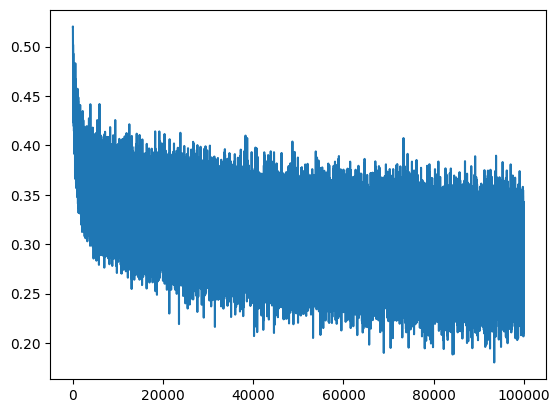

In [14]:
plt.plot(list(range(EPOCHS)), losses)

# Eval Model with Dev Data

In [15]:
@torch.no_grad()
def calc_loss(inputs, labels):
    embed = C[inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, labels)
    return loss

print(f"Train loss: {calc_loss(train_inputs, train_labels).item()}")
print(f"Dev loss: {calc_loss(dev_inputs, dev_labels).item()}")

Train loss: 1.9328545331954956
Dev loss: 2.039097785949707


In [8]:
# Best train loss: 1.8334664106369019
# Best dev loss: 2.0098631381988525

# Sample from the model

In [16]:
NUM_SAMPLES = 20
g = torch.Generator(device=torch_device).manual_seed(2147483647 + 10)
for _ in range(NUM_SAMPLES): 
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        embed = C[torch.tensor([context])]
        joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
        preact = joined_embed @ weights1
        batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
        layer1_out = torch.tanh(batch_norm_preact)
        logits = layer1_out @ weights2 + bias2
        probs = tfunc.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
  
    print(''.join(indx_to_char[i] for i in out)) # decode and print the generated word

graytlangelo.
ezengen.
brenq.
rwin.
rosetcersie.
jercen.
einel.
cales.
lilyah.
ryanna.
visham.
bria.
kasia.
elloree.
mues.
hustyn.
kayla.
tingsa.
janilah.
maquan.
